In [5]:
# sage -n jupyter --no-browser

import os, sys
from pathlib import Path

print("Working directory:", os.getcwd())
print("Kernel executable:", sys.executable)

if 'sage' in sys.executable.lower():
  target = Path("/mnt/d/Projects/m2-bezout/internship/src/notebooks/")
  os.chdir(target)
  print("Changed working directory to:", os.getcwd())

from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from type_checking import *


import importlib

from utils import styled_print

# import monte_carlo
# importlib.reload(monte_carlo)
# from monte_carlo import sample_from_empirical, plot_distribution, pmf_to_particles, MeanOneGenerator, wasserstein

Working directory: /mnt/d/Projects/m2-bezout/internship/src/notebooks
Kernel executable: /home/chocomint/miniconda3/envs/sage/bin/python3
Changed working directory to: /mnt/d/Projects/m2-bezout/internship/src/notebooks


In [52]:
u, v = var("u v")
x = var("x")
alpha = var("alpha")

g(x) = (u+v)*x^alpha + u*(1-x)^alpha

x_star = (1+(1+v/u)^(1/(alpha-1)))^(-1)

g_x_star = g(x_star).full_simplify()

In [53]:
styled_print(g_x_star)

<IPython.core.display.Math object>

In [71]:
u_val = 0.8
v_val = 0

alpha_val = 2*(u_val + v_val) - 1

g_x_star_num = g_x_star.subs(u=u_val, v=v_val, alpha=alpha_val).n()
g_x_star_num

1.05560632861832

Grid points with g(x*) > 1: 875/32400 (2.70%)
Grid points in region 2u+v>1: 24390/32400 (75.28%)
Points with g(x*)>1 inside 2u+v>1: 875


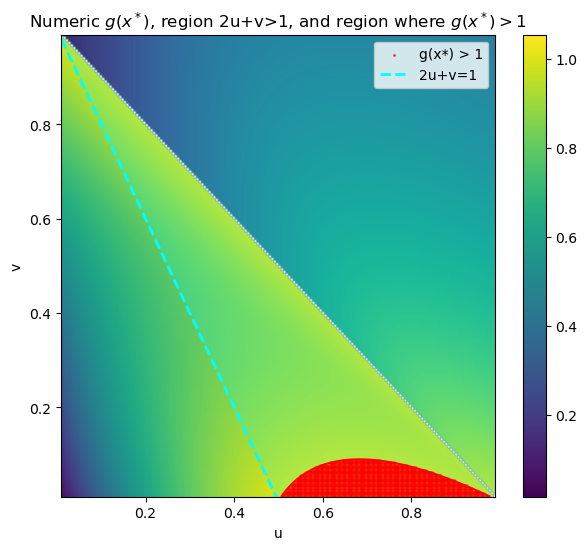

In [72]:
# Grid / heatmap of g_x_star over (u, v)
# Highlights region where g(x*) > 1 and the region 2u+v>1.
import numpy as np
import matplotlib.pyplot as plt
from math import isfinite

# ranges (avoid u=0 and alpha close to 1 which makes x_star ill-defined)
u_vals = np.linspace(0.01, 0.99, 180)
v_vals = np.linspace(0.01, 0.99, 180)

G = np.full((len(v_vals), len(u_vals)), np.nan)

for i, v_val in enumerate(v_vals):
    for j, u_val in enumerate(u_vals):
        alpha_val = 2*(u_val + v_val) - 1
        # skip problematic parameter combos
        if abs(alpha_val - 1) < 1e-9 or u_val == 0:
            continue
        try:
            val = g_x_star.subs(u=u_val, v=v_val, alpha=alpha_val).n()
            valf = float(val)
            if isfinite(valf):
                G[i, j] = valf
        except Exception:
            try:
                val = g_x_star.subs({u: u_val, v: v_val, alpha: alpha_val}).n()
                valf = float(val)
                if isfinite(valf):
                    G[i, j] = valf
            except Exception:
                G[i, j] = np.nan

# Boolean mask where g_x_star > 1 (treat NaNs as False)
mask_exceeds = np.logical_and(~np.isnan(G), G > 1.0)
points_count = int(np.count_nonzero(mask_exceeds))
total = G.size
fraction = points_count / total if total > 0 else 0.0

U, V = np.meshgrid(u_vals, v_vals)
# region where 2u+v > 1
region_mask = (2*U + V) > 1
region_count = int(np.count_nonzero(region_mask))
intersect_count = int(np.count_nonzero(np.logical_and(mask_exceeds, region_mask)))

print(f"Grid points with g(x*) > 1: {points_count}/{total} ({fraction*100:.2f}%)")
print(f"Grid points in region 2u+v>1: {region_count}/{total} ({region_count/total*100:.2f}%)")
print(f"Points with g(x*)>1 inside 2u+v>1: {intersect_count}")

# Mask NaNs for plotting
G_masked = np.ma.masked_invalid(G)

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(
    G_masked,
    origin='lower',
    aspect='auto',
    extent=(u_vals[0], u_vals[-1], v_vals[0], v_vals[-1]),
    cmap='viridis',
)
# shade region 2u+v>1 (transparent cyan)
try:
    ax.contourf(U, V, region_mask.astype(float), levels=[0.5, 1.5], colors=['cyan'], alpha=0.18)
except Exception:
    pass
# contour line at g(x*) = 1
try:
    cs = ax.contour(U, V, G_masked, levels=[1.0], colors='red', linewidths=1.5)
    cs.collections[0].set_label('g(x*) = 1')
except Exception:
    idxs = np.where(mask_exceeds)
    ax.scatter(u_vals[idxs[1]], v_vals[idxs[0]], s=1, c='red', alpha=0.7, label='g(x*) > 1')

# overlay points where g>1
if points_count > 0:
    idxs = np.where(mask_exceeds)
    ax.scatter(u_vals[idxs[1]], v_vals[idxs[0]], s=6, c='red', alpha=0.4)

# draw line 2u+v=1
v_line = 1.0 - 2.0*u_vals
ax.plot(u_vals, v_line, color='cyan', linestyle='--', linewidth=2, label='2u+v=1')

ax.set_xlim(u_vals[0], u_vals[-1])
ax.set_ylim(v_vals[0], v_vals[-1])
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_title(r'Numeric $g(x^*)$, region 2u+v>1, and region where $g(x^*)>1$')
cbar = fig.colorbar(im, ax=ax)
ax.legend(loc='upper right')
plt.show()